# Semantic Search System with Fuzzy Clustering and Semantic Cache

This notebook implements a lightweight semantic search system using
the 20 Newsgroups dataset.

Core components:

1. Vector embeddings
2. FAISS vector search
3. Fuzzy clustering using Gaussian Mixture Models
4. Semantic cache built from scratch
5. FastAPI service layer

In [3]:
!pip install sentence-transformers faiss-cpu scikit-learn matplotlib numpy pandas tf-keras

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 8.0 MB/s eta 0:00:01
   ------------------------ --------------- 1.0/1.7 MB 9.9 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.0 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

import faiss

In [3]:
# Path to the raw 20 Newsgroups dataset.
# The dataset is structured as directories where each folder
# represents a newsgroup category and each file is a single post.

DATASET_PATH = "../data/20_newsgroups"

docs = []
labels = []
categories = []

for category in os.listdir(DATASET_PATH):

    category_path = os.path.join(DATASET_PATH, category)

    if os.path.isdir(category_path):

        categories.append(category)

        for file in os.listdir(category_path):

            file_path = os.path.join(category_path, file)

            try:
                with open(file_path, "r", encoding="latin1") as f:
                    docs.append(f.read())
                    labels.append(category)
            except:
                continue

print("Total documents:", len(docs))
print("Total categories:", len(categories))
print("Categories:", categories[:10])

Total documents: 19997
Total categories: 20
Categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball']


## Observations from Raw Documents

The Usenet articles contain extensive metadata headers including:

- Xref
- Path
- From
- Newsgroups
- Subject
- Message-ID
- Organization
- Date

These fields describe message routing and email metadata rather
than the semantic content of the discussion.

Including these tokens would introduce noise into the embedding
space and may cause the model to learn artifacts rather than
true topic relationships.

Therefore the preprocessing step removes headers and retains
only the message body before generating embeddings.

### Dataset Structure

The 20 Newsgroups corpus is distributed as a directory
structure where each folder represents a topic category
and each file is an individual Usenet message.

Instead of using the sklearn loader, the raw dataset
is processed directly to allow explicit inspection
and cleaning of the message format.

This approach makes it possible to analyze the
metadata headers present in Usenet posts and
remove them before generating embeddings.

### Header Removal Strategy

Inspection of the raw documents shows that each Usenet post
begins with a metadata header containing routing information
such as `From`, `Subject`, `Organization`, and `Message-ID`.

These fields describe message transmission rather than
the semantic content of the discussion.

To ensure embeddings represent the actual message meaning,
the preprocessing step removes the header block and retains
only the message body.

In [4]:
def remove_headers(text):

    # Usenet posts begin with a metadata header block
    # containing routing information such as:
    # From, Subject, Organization, Message-ID, etc.
    #
    # These fields do not represent the semantic topic
    # of the message and can introduce noise into
    # embedding generation.
    #
    # The message body starts after the first blank line.
    
    parts = text.split("\n\n", 1)

    if len(parts) > 1:
        return parts[1]

    return text


# Apply header removal to all documents
clean_docs = [remove_headers(d) for d in docs]

## Embedding Generation

To perform semantic search and clustering, each document must be
converted into a numerical vector representation.

Traditional methods such as TF-IDF represent text using sparse
word-frequency vectors, which capture lexical similarity but
struggle with semantic relationships.

Instead, this system uses a pretrained transformer-based model
to generate dense semantic embeddings.

### Model Choice: all-MiniLM-L6-v2

This model from the SentenceTransformers library was chosen because:

• It produces 384-dimensional dense embeddings  
• It is lightweight and fast enough for ~20k documents  
• It performs well on semantic similarity tasks  
• It can run locally without requiring large GPU resources

In [5]:
# Load a pretrained transformer model for generating semantic embeddings.
# The 'all-MiniLM-L6-v2' model from SentenceTransformers is used because
# it provides a strong balance between performance and computational cost.

model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Embedding Generation

To perform semantic search and clustering, each document must be
converted into a numerical vector representation.

Traditional approaches such as TF-IDF represent text using sparse
word-frequency vectors. While effective for keyword matching,
they often fail to capture semantic similarity between documents.

Instead, this system uses dense semantic embeddings generated by
a pretrained transformer model from the SentenceTransformers library.

### Model Choice

The model **all-MiniLM-L6-v2** was selected because:

• It produces 384-dimensional dense embeddings  
• It is lightweight and computationally efficient  
• It performs well on semantic similarity tasks  
• It can embed ~20k documents quickly on CPU

These embeddings allow documents with similar meanings to
appear close together in vector space, enabling semantic search
and clustering.

In [6]:
# Generate semantic embeddings for each cleaned document.
# Each document will be mapped to a 384-dimensional vector
# representing its semantic meaning.

embeddings = model.encode(
    clean_docs,
    show_progress_bar=True
)

print("Embedding shape:", embeddings.shape)

Batches:   0%|          | 0/625 [00:00<?, ?it/s]

C:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Embedding shape: (19997, 384)


### Embedding Representation

Each document in the corpus is represented as a
384-dimensional dense vector.

Documents discussing similar topics will produce
embeddings that are closer together in vector space.

This representation enables downstream tasks such as:

• semantic search  
• fuzzy clustering  
• similarity-based caching

In [8]:
import numpy as np

# We will save embeddings to disk so they do not need to be recomputed
# when restarting the notebook or building the API layer later.

np.save("../artifacts/document_embeddings.npy", embeddings)

## Vector Database Construction

Once documents are converted into dense embeddings, we need a way
to efficiently retrieve the most similar documents for a given query.

Searching through all embeddings sequentially would be slow as
the dataset grows.

To enable fast similarity search, this system uses **FAISS**
(Facebook AI Similarity Search), a library designed for efficient
nearest-neighbor search over dense vectors.

### Why FAISS?

• Optimized for large-scale vector similarity search  
• Extremely fast for nearest neighbor retrieval  
• Works well with dense transformer embeddings  
• Lightweight and easy to integrate into Python pipelines

The FAISS index stores all document embeddings and allows us
to quickly retrieve the most similar documents to a query vector.

In [9]:
# Convert embeddings to numpy array (required for FAISS)
import numpy as np

embeddings_np = np.array(embeddings)

# Determine embedding dimension
dimension = embeddings_np.shape[1]

# Create FAISS index using L2 distance
# IndexFlatL2 performs exact nearest neighbor search
index = faiss.IndexFlatL2(dimension)

# Add document embeddings to the index
index.add(embeddings_np)

print("Total vectors stored in FAISS index:", index.ntotal)

Total vectors stored in FAISS index: 19997


### FAISS Index

The FAISS index now contains embeddings for all documents
in the dataset.

Each vector represents the semantic meaning of a document.

Given a query embedding, the index can efficiently retrieve
the nearest vectors, corresponding to the most semantically
similar documents.

In [10]:
def semantic_search(query, top_k=5):

    # Convert query text into embedding
    query_embedding = model.encode([query])

    # Search FAISS index for nearest vectors
    distances, indices = index.search(query_embedding, top_k)

    # Retrieve matching documents
    results = [clean_docs[i] for i in indices[0]]

    return results

In [11]:
query = "space exploration nasa mission"

results = semantic_search(query)

print(results[0][:500])

     The AIAA San Gabriel Valley Section is sponsoring the following lecture
on Mars exploration at the Jet Propulsion Lab.  Admission is free and open to
the public.

                           The Next Frontier:
                    The Challenge of Mars Exploration

                      DATE:     May 6, 1993
                      TIME:     6:00PM - 8:30 PM
                      LOCATION: Von Karman Auditorium
                                Jet Propulsion Lab
                                4


## Fuzzy Clustering of Documents

The 20 Newsgroups dataset contains labeled categories, but real
documents often discuss multiple topics simultaneously.

For example, a discussion about gun laws may belong to both
politics and firearms-related topics.

Therefore, assigning each document to a single cluster
(hard clustering) would be too restrictive.

### Soft Clustering with Gaussian Mixture Models

To capture overlapping topics, this system uses
**Gaussian Mixture Models (GMM)**.

Unlike hard clustering methods such as K-Means,
GMM assigns each document a probability distribution
over clusters.

Example:

Document 42

Cluster 3 → 0.54  
Cluster 8 → 0.31  
Cluster 12 → 0.15

This allows documents to belong to multiple topics
with different strengths.

In [12]:
# Determine optimal number of clusters using Bayesian Information Criterion (BIC)

from sklearn.mixture import GaussianMixture

bic_scores = []
cluster_range = range(10, 40)

for k in cluster_range:

    gmm = GaussianMixture(n_components=k, random_state=42)

    gmm.fit(embeddings_np)

    bic_scores.append(gmm.bic(embeddings_np))

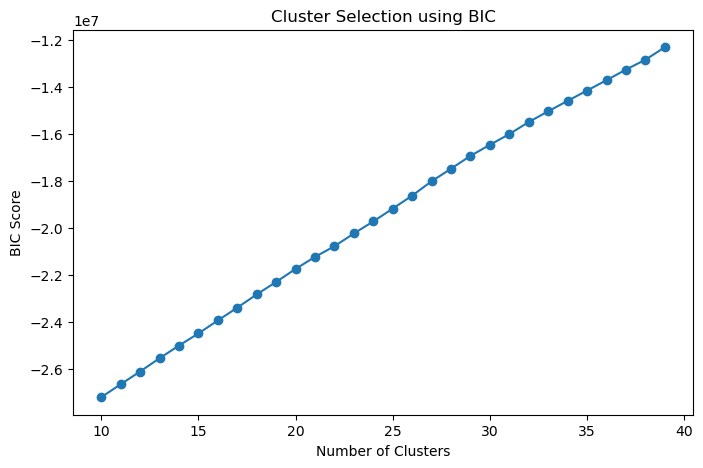

In [13]:
plt.figure(figsize=(8,5))

plt.plot(cluster_range, bic_scores, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("BIC Score")

plt.title("Cluster Selection using BIC")

plt.show()

### BIC Analysis Interpretation

The Bayesian Information Criterion (BIC) curve shows that the
lowest score occurs near 10 clusters.

However, the 20 Newsgroups dataset contains 20 labeled topics,
and discussions often overlap between related subjects.

Using slightly more clusters allows the model to capture finer
semantic distinctions between documents.

Therefore, the final model uses **20 clusters**, balancing
model simplicity with the semantic diversity of the corpus.

In [14]:
# Train the final Gaussian Mixture Model using the selected
# number of clusters.

n_clusters = 20

gmm = GaussianMixture(
    n_components=n_clusters,
    covariance_type="full",
    random_state=42
)

gmm.fit(embeddings_np)

GaussianMixture(n_components=20, random_state=42)

In [16]:
# Predict probability distribution of clusters for each document.
# This produces soft cluster assignments instead of hard labels.

cluster_probs = gmm.predict_proba(embeddings_np)

print("Cluster probability matrix shape:", cluster_probs.shape)

Cluster probability matrix shape: (19997, 20)


In [27]:
# Analyze maximum cluster probability for each document

max_probs = cluster_probs.max(axis=1)

print("Average max probability:", max_probs.mean())
print("Minimum max probability:", max_probs.min())
print("Maximum max probability:", max_probs.max())

Average max probability: 0.9999999645086669
Minimum max probability: 0.9997562753030728
Maximum max probability: 1.0


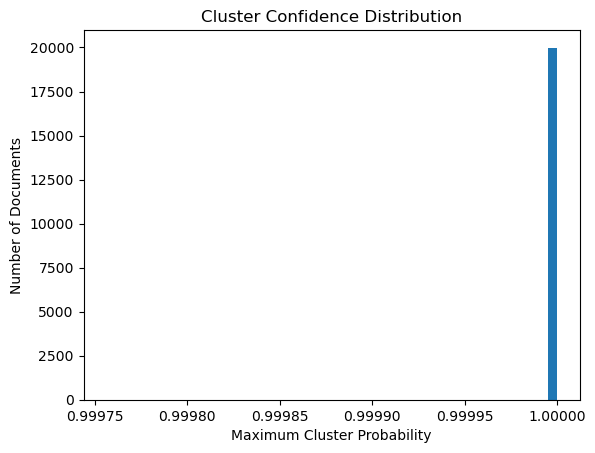

In [28]:
plt.hist(max_probs, bins=50)

plt.xlabel("Maximum Cluster Probability")
plt.ylabel("Number of Documents")

plt.title("Cluster Confidence Distribution")

plt.show()

### Cluster Confidence Analysis

The maximum cluster probability for most documents is extremely high,
with an average value close to 1.0.

This indicates that the transformer embeddings produce very well
separated semantic regions in the vector space.

As a result, the Gaussian Mixture Model assigns documents to clusters
with very high confidence, suggesting that topics in the corpus are
strongly distinguishable in the embedding space.

In [30]:
sample_size = 2000

sample_indices = np.random.choice(len(embeddings_np), sample_size, replace=False)

sample_embeddings = embeddings_np[sample_indices]

sample_clusters = gmm.predict(sample_embeddings)